<a href="https://colab.research.google.com/github/thuyntp26/LinearRegression/blob/main/hoiquy_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LOAD DỮ LIỆU VÀ KIỂM TRA DỮ LIỆU**

In [16]:
import pandas as pd
import csv

# Đọc dữ liệu từ URL raw
df = pd.read_csv("https://raw.githubusercontent.com/thuyntp26/LinearRegression/refs/heads/main/StudentPerformanceFactors.csv")

print("Shape:", df.shape)
df.head()

Shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [17]:
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Column names:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

Data types:
Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities    

In [18]:
# =========================
# COLUMN GROUPING
# =========================
target_col = "Exam_Score"

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

if target_col in numeric_cols:
    numeric_cols.remove(target_col)

print("Target column:", target_col)
print("\nNumeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Target column: Exam_Score

Numeric columns:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Categorical columns:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [19]:
# =========================
# MISSING VALUE SUMMARY
# =========================
missing_df = df.isnull().sum().reset_index()
missing_df.columns = ["Feature", "Missing_Count"]
missing_df["Missing_Percentage"] = (missing_df["Missing_Count"] / len(df)) * 100
missing_df = missing_df[missing_df["Missing_Count"] > 0].sort_values(by="Missing_Count", ascending=False)

missing_df

,Feature,Missing_Count,Missing_Percentage
16,Parental_Education_Level,90,1.362192
11,Teacher_Quality,78,1.180566
17,Distance_from_Home,67,1.014076


In [22]:
# Summary stats for numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6607.0,7.029060,1.468120,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6607.0,1.493719,1.230570,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6607.0,2.967610,1.031231,0.0,2.0,3.0,4.0,6.0
Exam_Score,6607.0,67.235659,3.890456,55.0,65.0,67.0,69.0,101.0


count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64


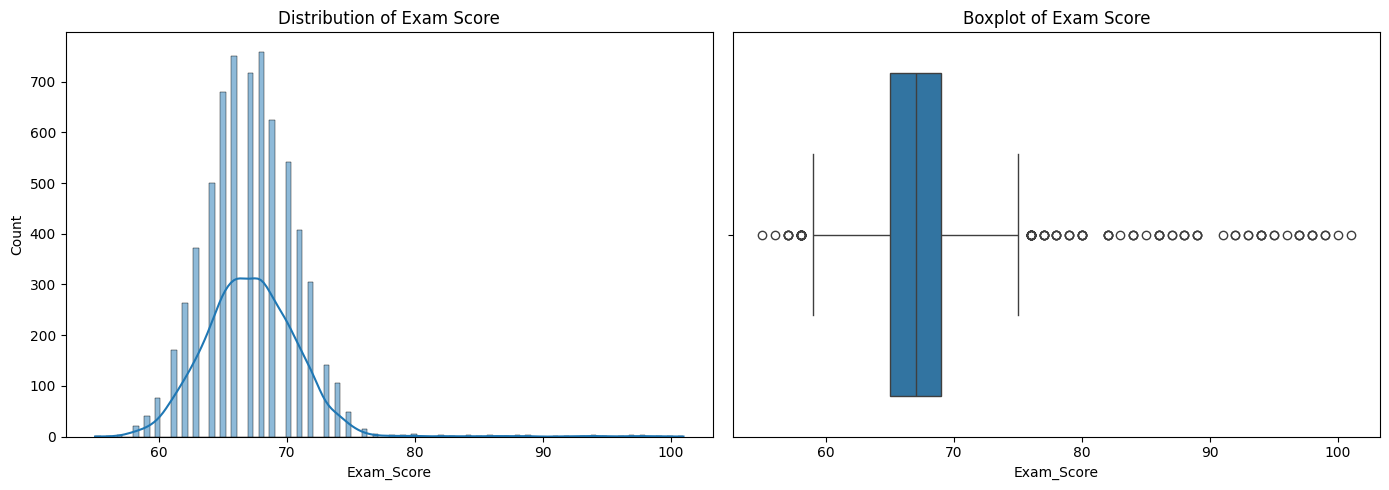

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# TARGET VARIABLE ANALYSIS
# =========================
print(df[target_col].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[target_col], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Exam Score")

sns.boxplot(x=df[target_col], ax=axes[1])
axes[1].set_title("Boxplot of Exam Score")

plt.tight_layout()
plt.show()

--> Nhận định: Phân bố điểm số gần như chuẩn, tập trung quanh mức ~67. Hầu hết học sinh nằm trong phạm vi điểm số hẹp (65–69). Một vài điểm số ngoại lệ cao (>90) đại diện cho những học sinh đạt điểm cao nhất. Kết quả học tập của học sinh tập trung khá chặt chẽ, cho thấy sự biến động hạn chế.

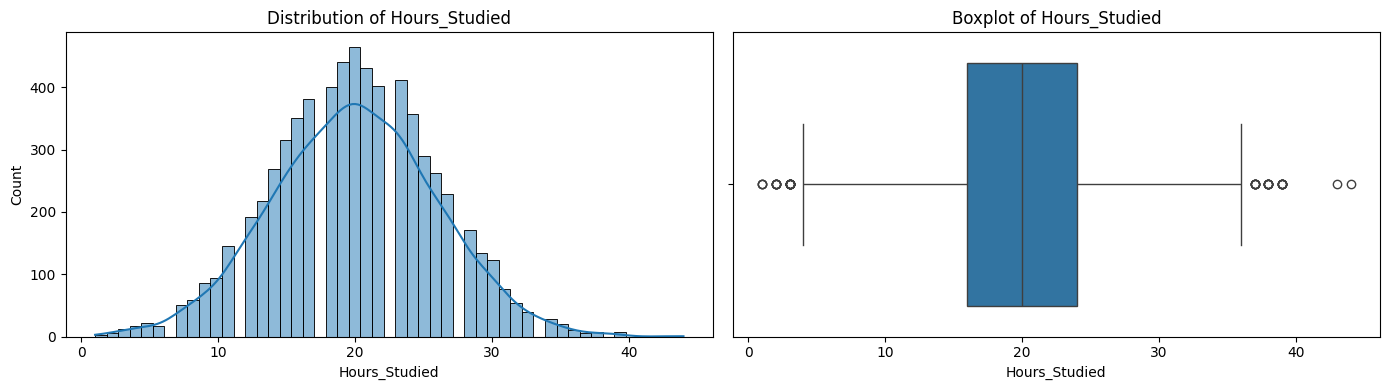

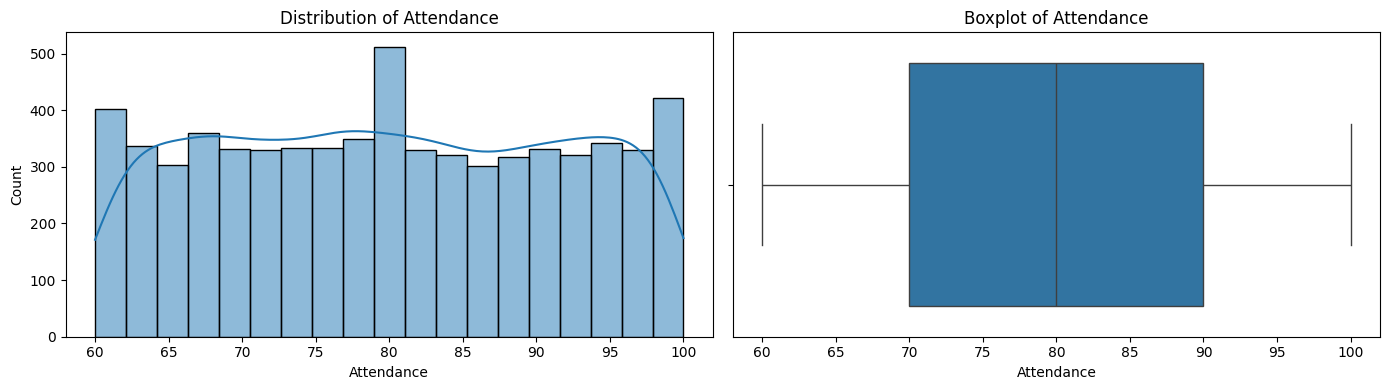

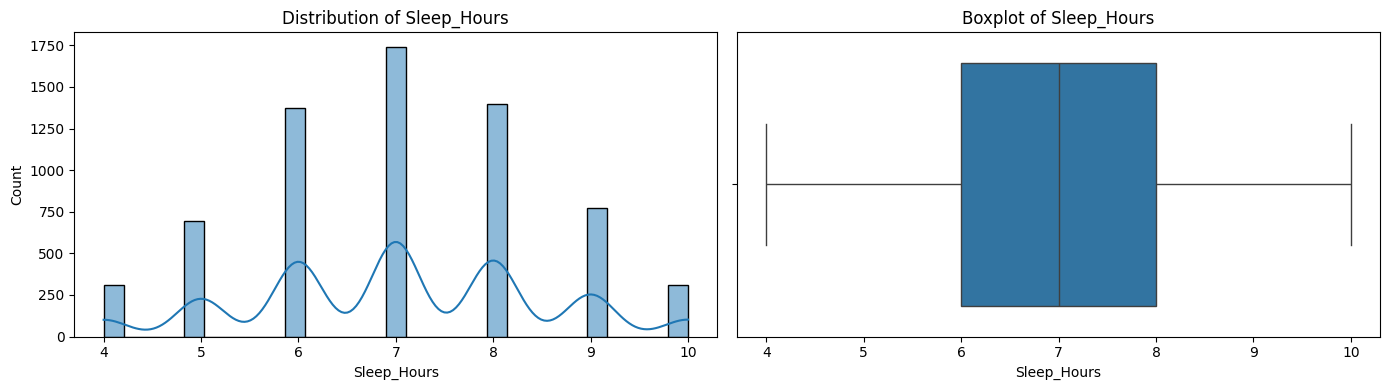

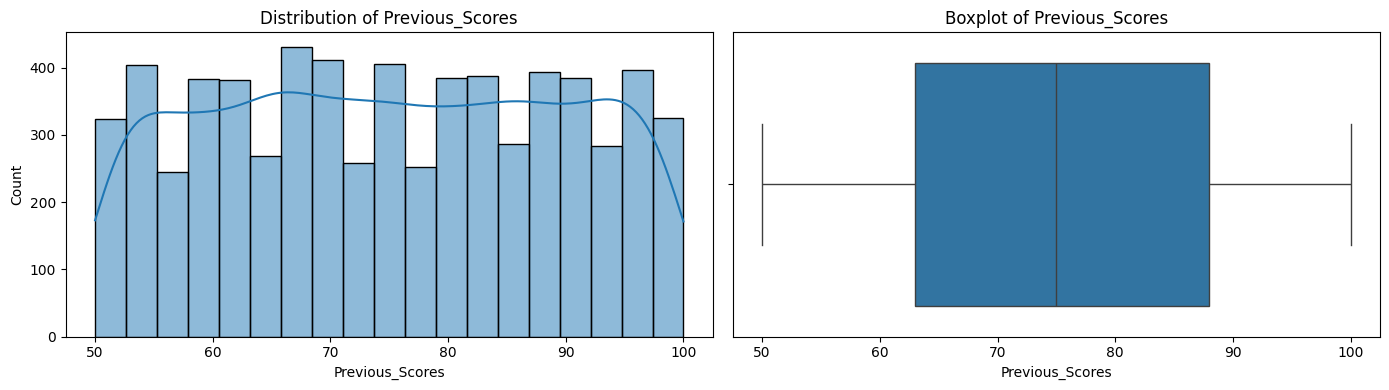

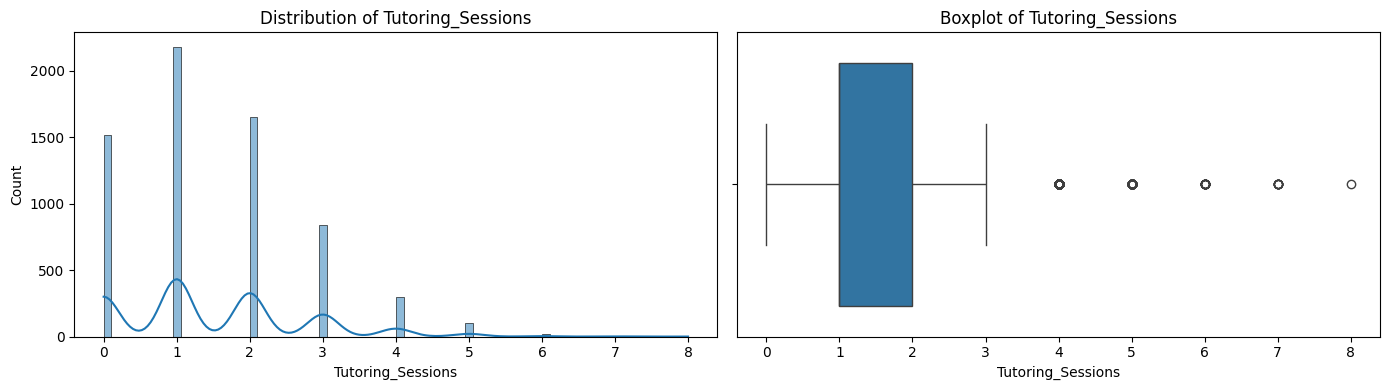

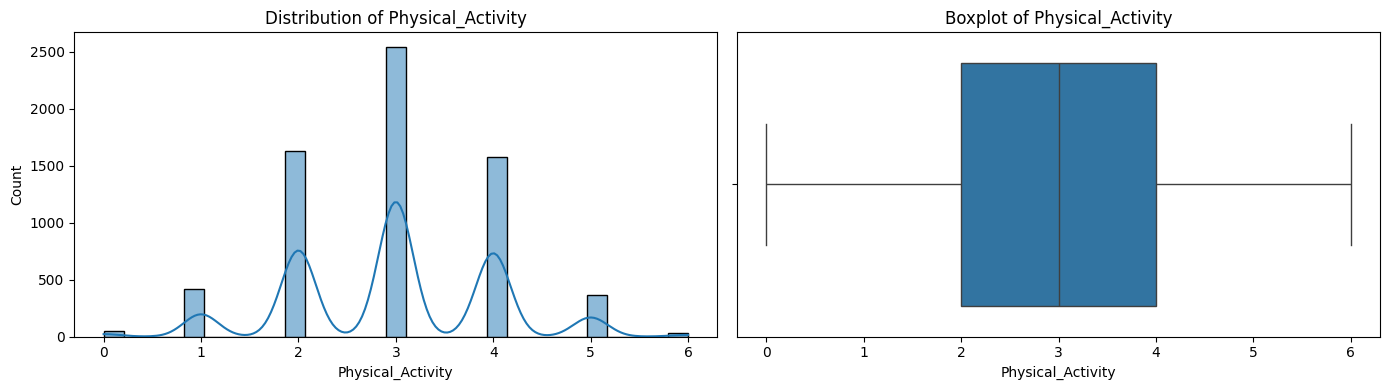

In [23]:
# =========================
# NUMERIC FEATURE DISTRIBUTIONS
# =========================
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")

    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

Nhận định: Số giờ học tuân theo phân phối gần chuẩn. Tỷ lệ tham dự phân bố đều trong khoảng 60–100. Số buổi học kèm riêng phân bố lệch phải (hầu hết sinh viên có ít buổi học). Số giờ ngủ và hoạt động thể chất là các biến rời rạc. Hầu hết các biến đều có tính chất tốt với độ lệch cực đoan tối thiểu.

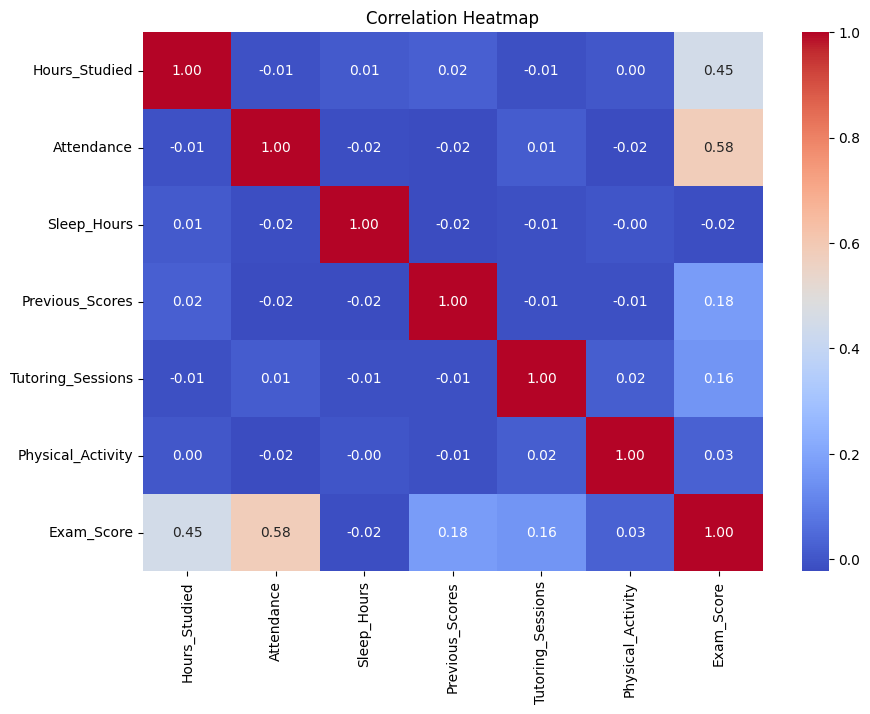

Exam_Score           1.000000
Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022
Name: Exam_Score, dtype: float64


In [24]:
# =========================
# CORRELATION ANALYSIS
# =========================
corr_matrix = df.select_dtypes(include=["int64", "float64"]).corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

target_corr = corr_matrix[target_col].sort_values(ascending=False)
print(target_corr)

Kết quả chính: Tỷ lệ tham dự có mối tương quan mạnh nhất (0,58), tiếp theo là số giờ học (0,45). Các biến số khác cho thấy mối quan hệ yếu đến trung bình. Tỷ lệ tham dự nổi lên như yếu tố có ảnh hưởng nhất.

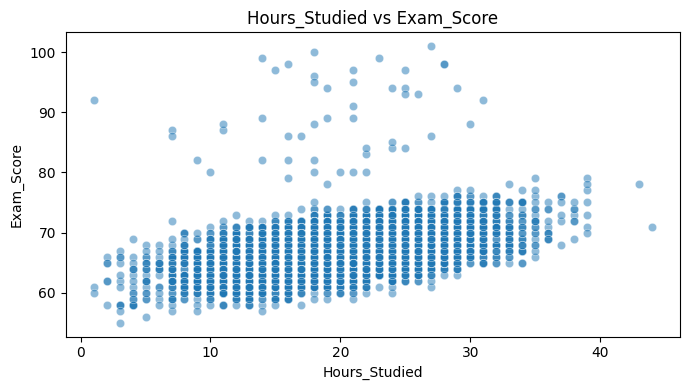

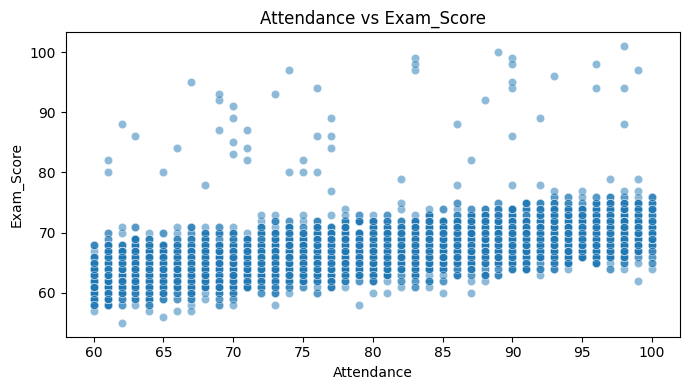

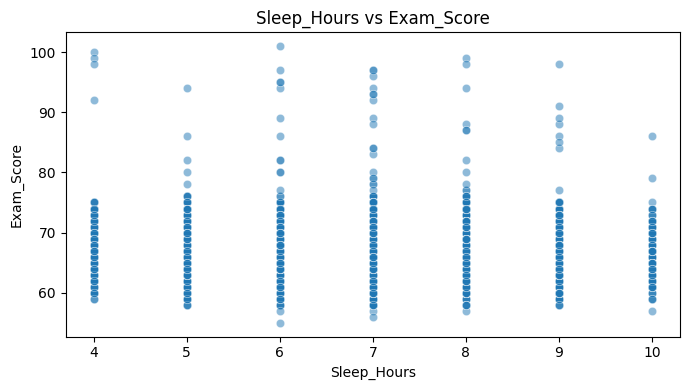

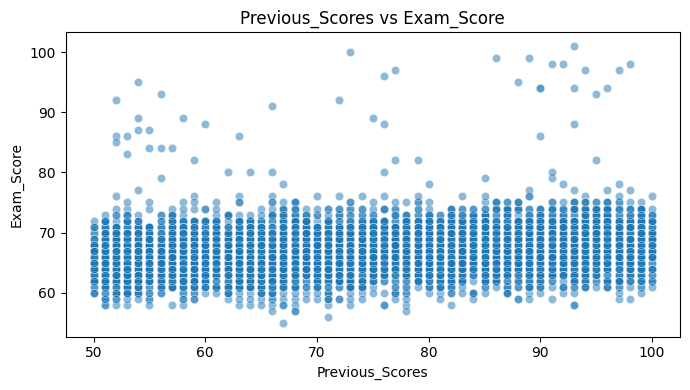

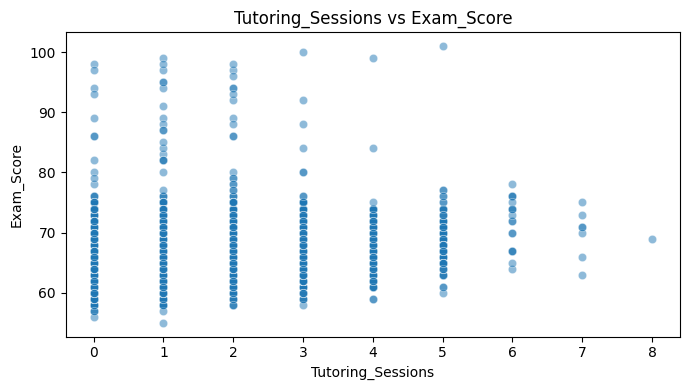

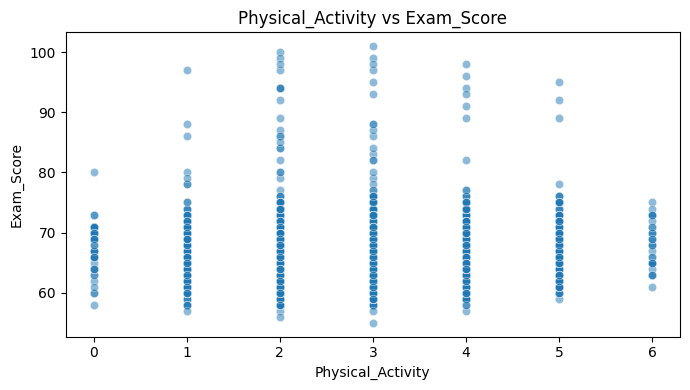

In [25]:
# =========================
# NUMERIC FEATURES VS TARGET
# =========================
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(data=df, x=col, y=target_col, alpha=0.5)
    plt.title(f"{col} vs {target_col}")
    plt.tight_layout()
    plt.show()

Nhận định: Thời gian học tập cho thấy xu hướng tích cực nhưng diễn ra từ từ. Tỷ lệ chuyên cần cho thấy mối quan hệ tăng mạnh. Giấc ngủ và hoạt động thể chất có tác động tối thiểu. Các biến số về sự tham gia chi phối kết quả học tập.

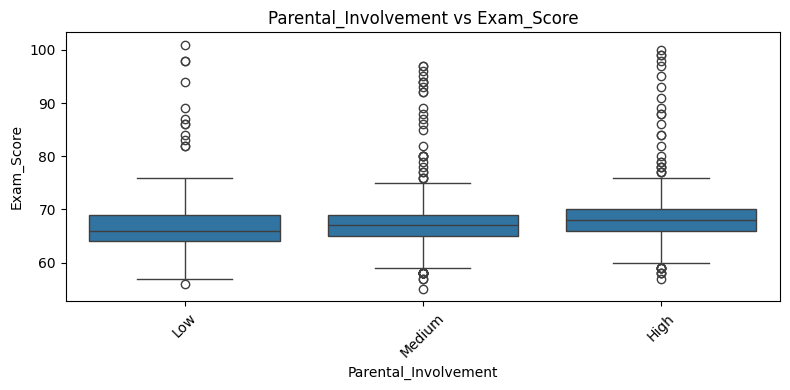

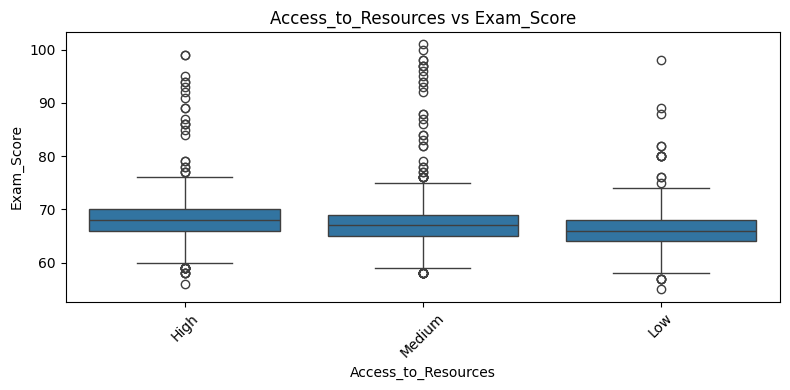

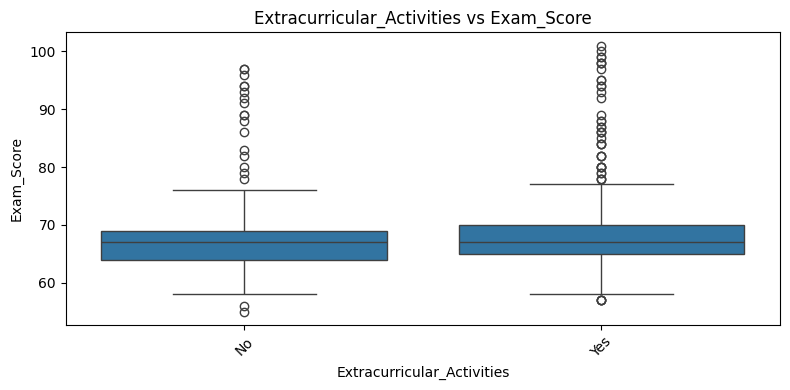

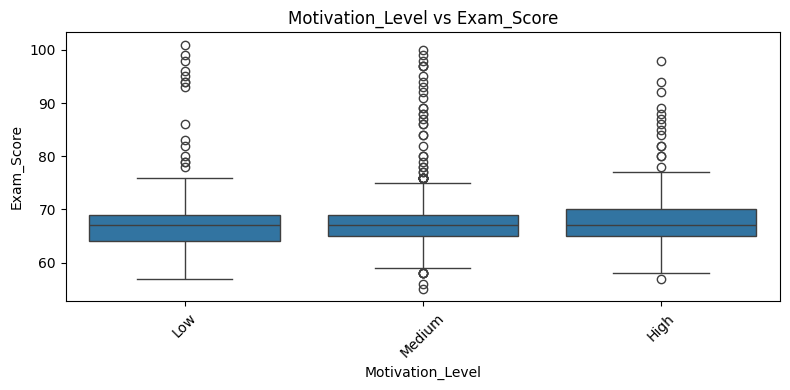

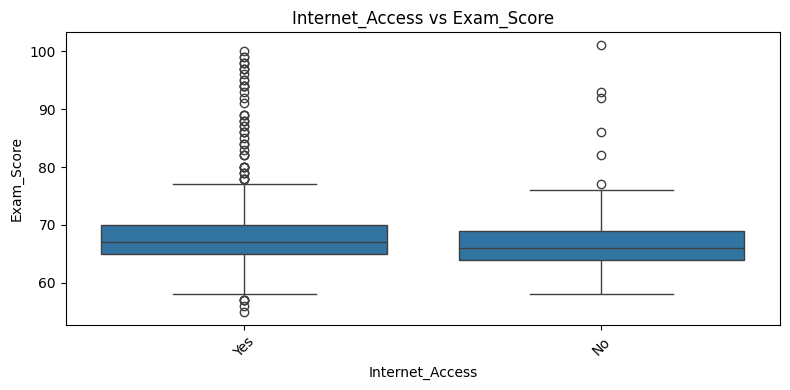

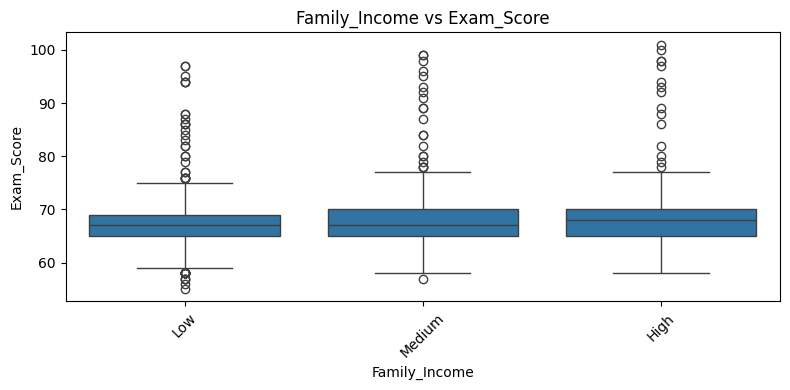

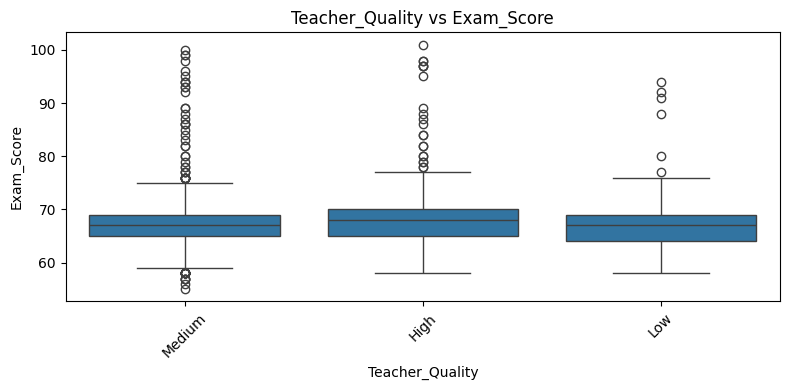

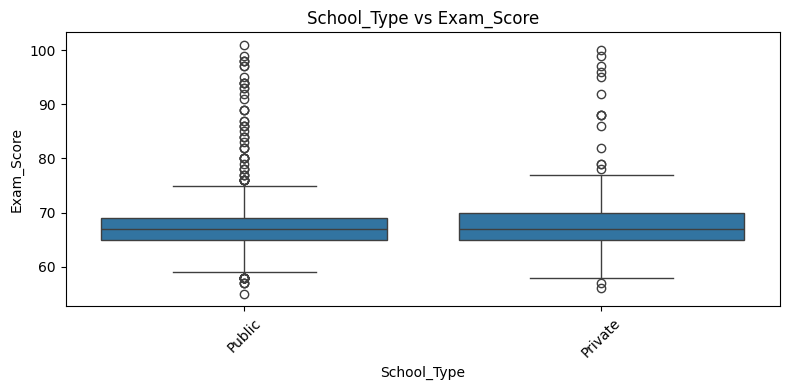

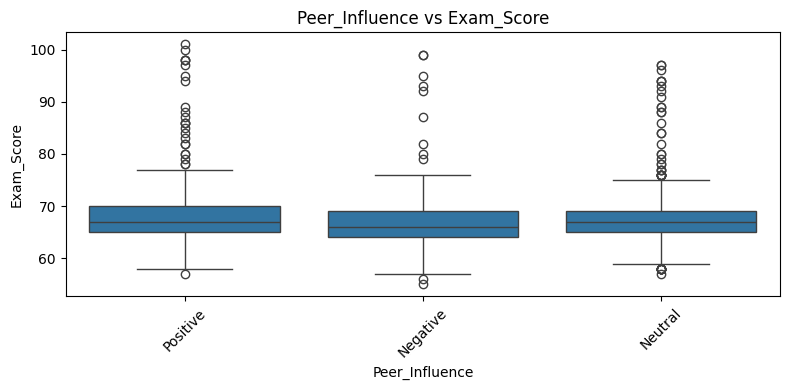

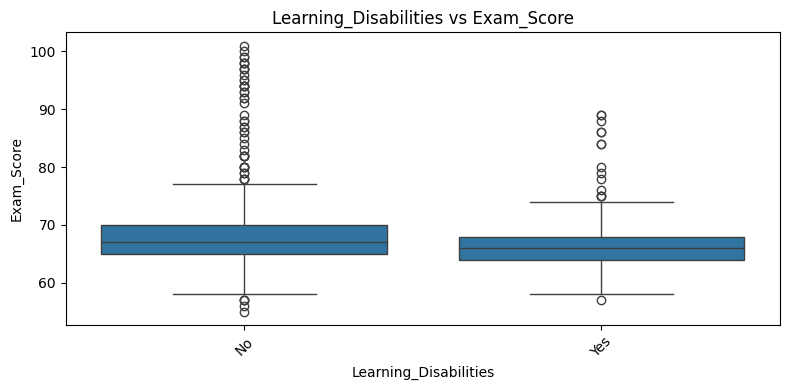

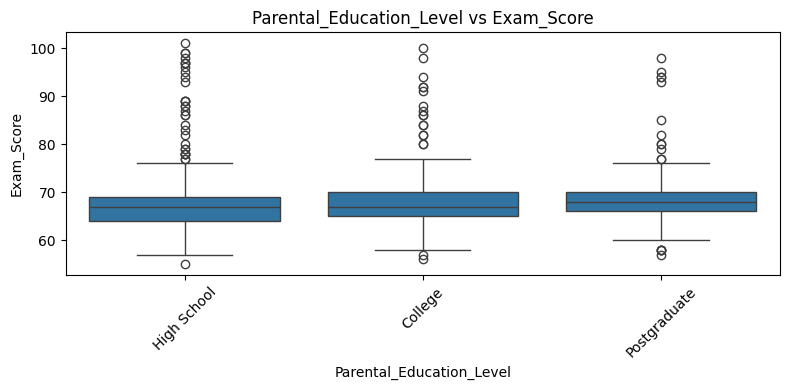

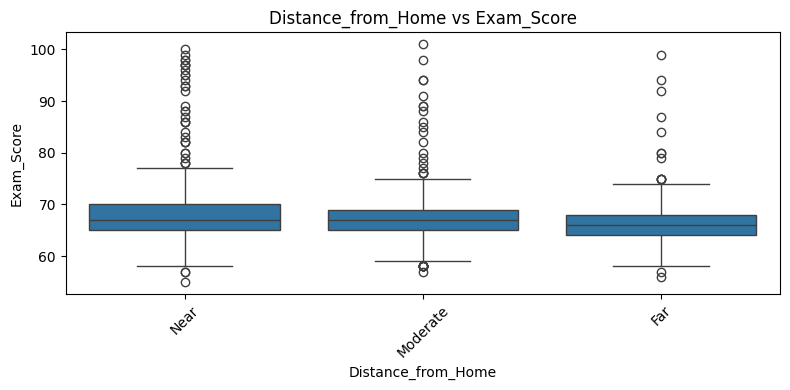

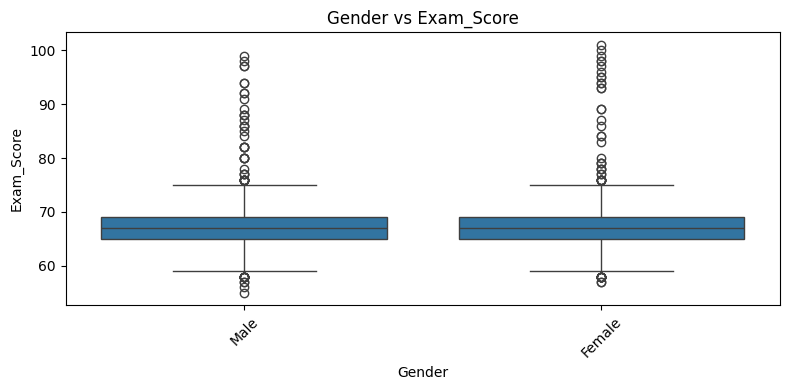

In [26]:
# =========================
# CATEGORICAL FEATURES VS TARGET
# =========================
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=col, y=target_col)
    plt.title(f"{col} vs {target_col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Nhận định: Sự tham gia tích cực của phụ huynh giúp cải thiện kết quả học tập; Mức độ động lực tác động mạnh mẽ đến kết quả; Chất lượng giáo viên đóng vai trò quan trọng; Giới tính và loại trường học cho thấy sự khác biệt tối thiểu; Các yếu tố về hành vi và hỗ trợ có tầm quan trọng hơn các yếu tố nhân khẩu học.

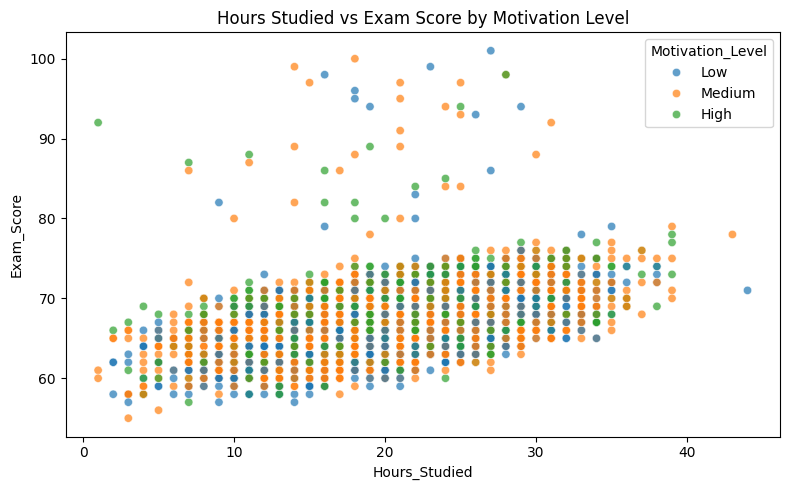

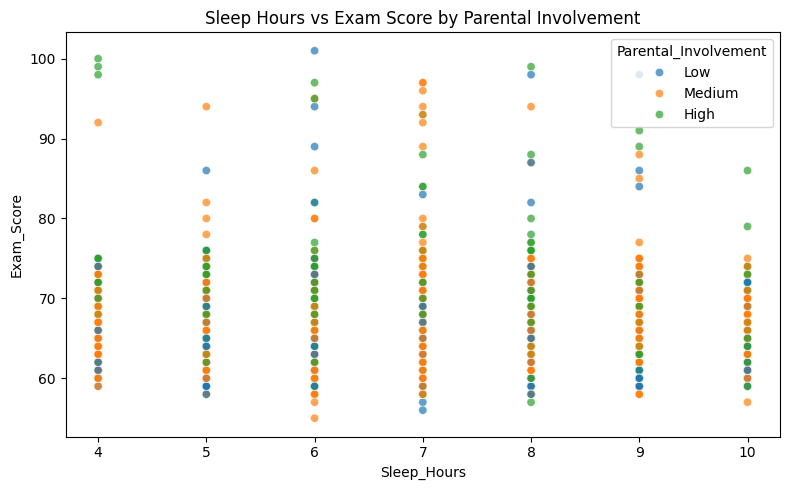

In [27]:
# =========================
# INTERACTION ANALYSIS
# =========================
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Hours_Studied",
    y="Exam_Score",
    hue="Motivation_Level",
    alpha=0.7
)
plt.title("Hours Studied vs Exam Score by Motivation Level")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Sleep_Hours",
    y="Exam_Score",
    hue="Parental_Involvement",
    alpha=0.7
)
plt.title("Sleep Hours vs Exam Score by Parental Involvement")
plt.tight_layout()
plt.show()

Nhận định: Động lực thúc đẩy hiệu quả của thời gian học tập. Sự tham gia của phụ huynh cải thiện kết quả trong mọi điều kiện. Hiệu suất bị ảnh hưởng bởi các yếu tố tương tác, chứ không phải các biến số riêng lẻ

In [28]:
# =========================
# TRAIN-TEST SPLIT
# =========================
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

NameError: name 'train_test_split' is not defined